In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statistics import mode
import folium
from folium.plugins import MarkerCluster
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import random
from sklearn.impute import SimpleImputer
from typing import Dict
import seaborn as sns
from sklearn.impute import SimpleImputer
from IPython.display import display, HTML
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

In [3]:
from typing import List, Tuple
from Algorithms.CDREC import CDRec
from Algorithms.TKCM import TKCM
from Algorithms.TKCM_Weighted import TKCM_Weighted
from Algorithms.DynaMMO import DynaMMo
from Algorithms.SoftImpute import SoftImpute
from Algorithms.SVDImpute import IterativeSVD
from Algorithms.trmf import TRMFImputer
from Algorithms.ST_MVL import ST_MVL
from Algorithms.TKCM_PLUS import TKCM_PLUS
from Algorithms.TKCM_PRO import TKCM_PRO


In [4]:

# # Load dataset
valley_df = pd.read_csv("D:\\Thesis\\Project\\Data\\valley_data.csv")

# Count different types of missingness
stats = {
    "Total Rows": len(valley_df),
    "Total Columns": len(valley_df.columns),
    "Zero Values": (valley_df == 0).sum().sum(),
    "NaN Values": valley_df.isna().sum().sum(),
    "Blank Strings": (valley_df == "").sum().sum(),
    "Unknown Strings": (valley_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,7079427
1,Total Columns,6
2,Zero Values,1667902
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


In [5]:
valley_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,37100MS,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-10.4
1,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-8.9
2,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-9.5
3,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-8.1
4,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-8.8


In [6]:
valley_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079427 entries, 0 to 7079426
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 324.1+ MB


In [7]:
valley_df.describe()

,value
count,7.079427e+06
mean,1.722966e+02
std,3.336668e+02
min,-9.760000e+01
25%,0.000000e+00
50%,3.600000e+00
75%,1.000000e+02
max,1.474800e+03


In [8]:
# Preview data
print("🔍 Shape:", valley_df.shape)

🔍 Shape: (7079427, 6)


In [9]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", valley_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


In [10]:
unique_values = valley_df['sensor_code'].unique()
unique_values

array(['LT', 'N', 'WR', 'WG', 'WG.BOE', 'LF', 'LD.RED', 'GS', 'SD', 'HS',
       'W', 'WT'], dtype=object)

In [11]:
unique_values1 = valley_df['station_code'].unique()
unique_values1

array(['37100MS', '20500MS', '19300MS', '80300MS', '50500MS', '34500MS',
       '56900MS', '54500MS', '69900MS', '09700MS', '82200MS', '88820MS',
       '59700MS', '85120MS', '83200MS', '86900MS', '39100MS', '08200MS',
       '23200MS', '47400MS', '86600MS', '37700MS', '74900MS', '89190MS',
       '22210MS', '25900MS', '73500MS', '68600MS', '02200MS', '03100MS',
       '41000MS', '75600MS', '62600MS', '74200MS', '11400MS', '02500MS',
       '33500MS', '44500MS', '06400MS', '65600MS', '24400MS', '43200MS',
       '78305MS', '56500MS', '42700MS', '15800MS', '65350MS', '89950SE',
       '02250SE', '78150SE', '82910MS', '47150SE', '27100MS', '89155SE',
       '89355SE', '85700MS', '89055SE', '42150SE', '39050SE', '79450SE',
       '87300MS', '66500MS', '20910MS', '31410MS', '78110MS', '61300MS',
       '01110MS', '71510MS', '79300MS', '75510SE', '90150SE', '91510MS'],
      dtype=object)

In [12]:
unique_values2 = valley_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Precipitazioni', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Pressione atmosferica', 'Radiazione globale ',
       'Durata soleggiamento', 'Altezza neve al suolo',
       'Livello idrometrico', 'Temperatura acqua'], dtype=object)

In [13]:
unique_values3 = valley_df['unit'].unique()
unique_values3

array(['°C', 'mm', '° ', 'm/s', '%', 'hPa', 'W/m²', 's', 'cm'],
      dtype=object)

In [14]:
unique_values4 = valley_df['value'].unique()
unique_values4

array([-10.4,  -8.9,  -9.5, ..., 981.9, 855.3, 802.7], shape=(11245,))

In [15]:
column_names = list(valley_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

In [16]:
zero_counts = (valley_df == 0).sum()
print(zero_counts)

station_code            0
sensor_code             0
description_it          0
unit                    0
timestamp               0
value             1667902
dtype: int64


In [17]:
valley_df[valley_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
116,37100MS,LT,Temperatura dell´aria,°C,2024-12-29 14:00:00,0.0
338,37100MS,LT,Temperatura dell´aria,°C,2024-12-24 23:00:00,0.0
426,37100MS,LT,Temperatura dell´aria,°C,2024-12-23 03:00:00,0.0
598,37100MS,LT,Temperatura dell´aria,°C,2024-12-19 13:00:00,0.0
637,37100MS,LT,Temperatura dell´aria,°C,2024-12-18 17:30:00,0.0


In [18]:
# Make sure 'value' is numeric
valley_df['value'] = pd.to_numeric(valley_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    valley_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


   sensor_code  total_entries  zero_count  zero_percentage
0            N         585918      565938        96.589967
1           SD         773271      643102        83.166445
2           GS         758400      438331        57.796809
3            W          83263        5222         6.271693
4           LT         889920        7619         0.856144
5           WG         713371        4772         0.668937
6           HS          29182         170         0.582551
7       WG.BOE         713371        2423         0.339655
8           WT          83262          60         0.072062
9           WR         713371         265         0.037148
10          LF         875328           0         0.000000
11      LD.RED         860770           0         0.000000


In [19]:
# Step 1: Select sensor `LF`
lf_df = valley_df[valley_df['sensor_code'] == 'LF'].copy()

In [20]:
# Step 2: Replace `0.0` values with NaN
lf_df.loc[lf_df['value'] == 0.0, 'value'] = np.nan

In [21]:
# Step 3: Pivot to wide format (timestamp × station_code)
lf_df['timestamp'] = pd.to_datetime(lf_df['timestamp'])
pivot_df = lf_df.pivot(index='timestamp', columns='station_code', values='value')

In [22]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [23]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

In [24]:
clean_df

station_code,01110MS,02200MS,02500MS,03100MS,06400MS,08200MS,09700MS,11400MS,15800MS,19300MS,...,82910MS,83200MS,85120MS,85700MS,86600MS,86900MS,87300MS,88820MS,89190MS,91510MS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,99.1,90.4,82.5,86.2,94.8,99.8,92.7,91.6,91.9,90.6,...,93.8,87.7,99.9,96.8,95.8,98.1,97.6,83.5,84.3,99.9
2023-01-01 00:30:00,98.1,90.8,80.8,84.9,97.1,99.8,91.1,92.1,92.7,91.7,...,91.8,87.0,99.9,97.7,94.5,97.0,97.5,82.7,84.3,99.9
2023-01-01 01:00:00,98.0,91.5,81.9,83.5,96.7,99.8,90.0,89.1,92.4,90.1,...,92.1,85.3,99.9,97.1,93.5,98.5,99.7,89.8,81.3,99.9
2023-01-01 01:30:00,99.7,92.6,81.1,85.3,97.7,99.8,89.4,88.5,93.3,89.2,...,95.1,84.2,99.9,98.8,92.5,99.2,96.4,90.6,83.9,99.9
2023-01-01 02:00:00,99.8,94.2,81.9,84.5,95.4,99.8,88.2,86.2,94.2,89.1,...,98.6,88.4,99.9,99.6,94.5,99.0,99.9,90.0,80.9,99.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,54.5,74.4,38.3,53.7,48.4,91.3,64.9,51.1,49.7,89.4,...,84.0,90.2,47.1,100.2,99.6,98.7,53.8,95.8,64.1,96.9
2024-12-31 22:30:00,54.7,75.9,41.8,56.0,46.0,91.3,67.3,51.9,50.2,90.5,...,84.5,88.9,48.7,100.2,99.1,100.0,54.0,99.0,61.4,96.0
2024-12-31 23:00:00,54.7,77.3,39.0,55.8,46.4,92.2,64.2,51.1,51.0,90.4,...,85.7,89.0,48.4,99.7,99.7,100.0,57.7,96.6,63.5,96.1


In [25]:
# Step 6: Pick a target station (first available column)
target_station = clean_df.columns[2]

In [26]:
target_station

'02500MS'

In [27]:
# Step 7: Compute Pearson correlations with all other stations
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

In [28]:
correlations

station_code
15800MS    0.860133
03100MS    0.856343
06400MS    0.820458
20910MS    0.815276
24400MS    0.812125
71510MS    0.806599
68600MS    0.800845
01110MS    0.791615
20500MS    0.790726
11400MS    0.787193
65600MS    0.757288
02200MS    0.756943
87300MS    0.755742
85120MS    0.755661
78110MS    0.751061
79300MS    0.736962
34500MS    0.730753
75600MS    0.725095
74200MS    0.723658
73500MS    0.720382
66500MS    0.720341
25900MS    0.701794
89190MS    0.688170
82200MS    0.681692
44500MS    0.661228
47400MS    0.660803
78305MS    0.656539
82910MS    0.645984
69900MS    0.640392
50500MS    0.635309
09700MS    0.633138
54500MS    0.627258
61300MS    0.615036
80300MS    0.614604
37700MS    0.610875
08200MS    0.609098
22210MS    0.560592
31410MS    0.544317
42700MS    0.535828
37100MS    0.530221
83200MS    0.519141
62600MS    0.510519
74900MS    0.487708
19300MS    0.482003
23200MS    0.477953
39100MS    0.473874
88820MS    0.465987
86900MS    0.454714
41000MS    0.453751
56500MS

In [29]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [30]:
top_refs

['15800MS', '03100MS']

In [31]:
final_df

station_code,02500MS,15800MS,03100MS
timestamp,,,
2023-01-01 00:00:00,82.5,91.9,86.2
2023-01-01 00:30:00,80.8,92.7,84.9
2023-01-01 01:00:00,81.9,92.4,83.5
2023-01-01 01:30:00,81.1,93.3,85.3
2023-01-01 02:00:00,81.9,94.2,84.5
...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7
2024-12-31 22:30:00,41.8,50.2,56.0
2024-12-31 23:00:00,39.0,51.0,55.8


In [32]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [33]:
pattern_df

station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,82.5,91.9,86.2,94.8
2023-01-01 00:30:00,80.8,92.7,84.9,97.1
2023-01-01 01:00:00,81.9,92.4,83.5,96.7
2023-01-01 01:30:00,81.1,93.3,85.3,97.7
2023-01-01 02:00:00,81.9,94.2,84.5,95.4
...,...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7,48.4
2024-12-31 22:30:00,41.8,50.2,56.0,46.0
2024-12-31 23:00:00,39.0,51.0,55.8,46.4


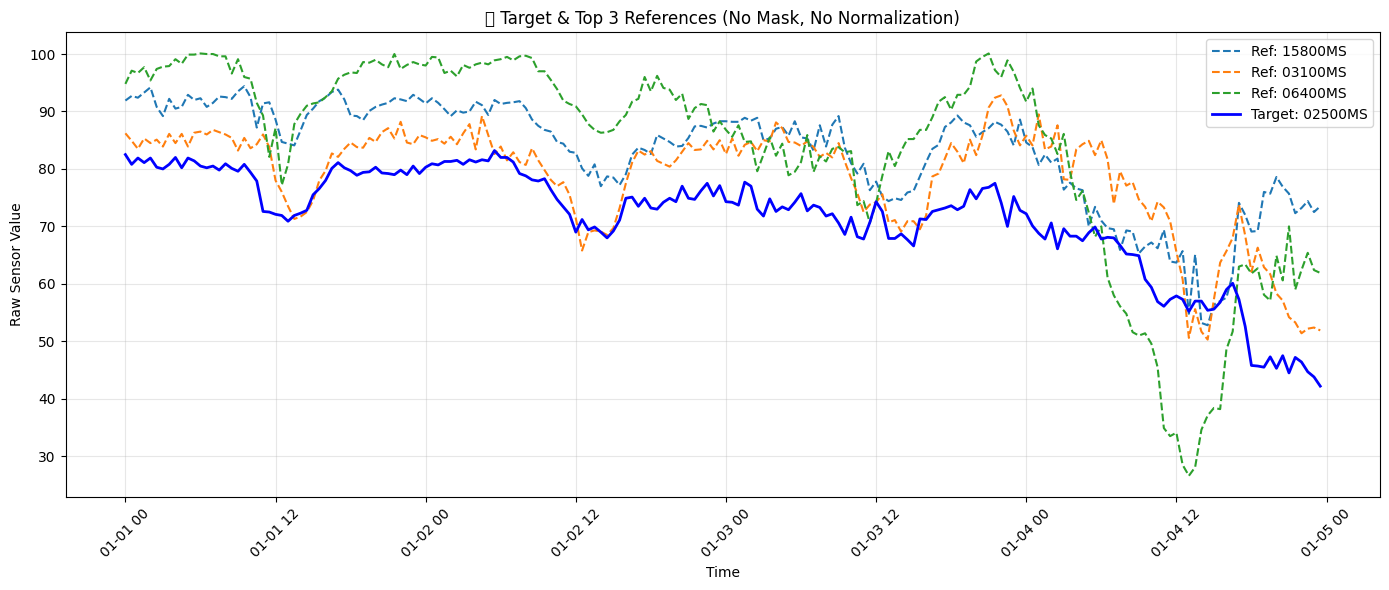

In [34]:
# Define the stations exactly as in your DataFrame
target = "02500MS"
references = ["15800MS","03100MS","06400MS"]

# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slice the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [35]:
pattern_df.isnull().sum()

station_code
02500MS    2
15800MS    2
03100MS    2
06400MS    2
dtype: int64

In [36]:
# Get rows where '02500MS' is NaN
nan_rows = pattern_df[pattern_df['02500MS'].isnull()]
print(nan_rows)

station_code         02500MS  15800MS  03100MS  06400MS
timestamp                                              
2023-02-14 14:00:00      NaN      NaN      NaN      NaN
2023-02-14 14:30:00      NaN      NaN      NaN      NaN


In [37]:
# Check for empty strings in '02500MS'
empty_strings = pattern_df[pattern_df['02500MS'] == ""]
print(empty_strings)

# Check for other placeholders (e.g., "NA")
placeholder_na = pattern_df[pattern_df['02500MS'] == "NA"]
print(placeholder_na)

Empty DataFrame
Columns: [02500MS, 15800MS, 03100MS, 06400MS]
Index: []
Empty DataFrame
Columns: [02500MS, 15800MS, 03100MS, 06400MS]
Index: []


In [38]:
pattern_df = pattern_df.dropna()

In [39]:
pattern_df.isnull().sum()

station_code
02500MS    0
15800MS    0
03100MS    0
06400MS    0
dtype: int64

In [40]:
# -------------------------------------------
# 🔹 STEP 1: Normalize the Time Series Data
# -------------------------------------------

from sklearn.preprocessing import StandardScaler

# 1️⃣ Initialize the Scaler
scaler = StandardScaler()

# 2️⃣ Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

# 3️⃣ Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print("✅ Normalized shape:", normalized_df.shape)
display(normalized_df.head())


✅ Normalized shape: (14591, 4)


station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,1.119923,1.189939,0.666856,1.250501
2023-01-01 00:30:00,1.038581,1.225965,0.609234,1.356561
2023-01-01 01:00:00,1.091214,1.212455,0.547179,1.338115
2023-01-01 01:30:00,1.052935,1.252984,0.626964,1.384229
2023-01-01 02:00:00,1.091214,1.293513,0.591504,1.278168


In [41]:
# ---------------------------------------------------------
# 🔹 STEP 2 (UPDATED): Inject Single Missing Points Across Entire Series
# ---------------------------------------------------------

def inject_single_point_global(series: pd.Series, missing_ratio: float = 0.1, random_state: int = 42) -> Tuple[pd.Series, np.ndarray, np.ndarray]:
    """
    Inject NaNs randomly throughout the entire time series.

    Parameters:
        series (pd.Series): Original complete time series.
        missing_ratio (float): Proportion of values to mask (default = 0.1).
        random_state (int): Seed for reproducibility.

    Returns:
        masked_series (pd.Series): Series with injected NaNs.
        missing_indices (np.ndarray): Indices where NaNs were inserted.
        true_values (np.ndarray): Original values at those indices.
    """
    ts = series.copy()
    n = len(ts)
    n_missing = int(n * missing_ratio)

    np.random.seed(random_state)
    missing_indices = np.random.choice(np.arange(n), size=n_missing, replace=False)
    true_values = ts.iloc[missing_indices].values

    ts.iloc[missing_indices] = np.nan
    return ts, missing_indices, true_values


In [42]:
# ---------------------------------------------------------
# 🔹 STEP 2b (UPDATED): Apply single-point missing injection across the entire series
# ---------------------------------------------------------

# 1️⃣ Define the target station (column in normalized_df)
target_station = "02500MS"

# 2️⃣ Inject missing values into the entire series (not just the end)
masked_target_series, missing_idx_array, true_values_array = inject_single_point_global(
    normalized_df[target_station], 
    missing_ratio=0.30  # 10% of the entire series will be masked
)

# 3️⃣ ✅ Print sample information about the injected points
print("🔢 Injected missing indices:", missing_idx_array[:5])
print("📉 True values at those indices:", true_values_array[:5])
print("🕓 Corresponding timestamps:", normalized_df.index[missing_idx_array[:5]])


🔢 Injected missing indices: [ 4676  8852   907 12038 11946]
📉 True values at those indices: [-0.88493206 -0.60262545  0.01940604  0.24907921 -0.03801225]
🕓 Corresponding timestamps: DatetimeIndex(['2023-11-11 11:00:00', '2024-02-06 11:00:00',
               '2023-01-19 21:30:00', '2024-11-08 20:00:00',
               '2024-11-06 22:00:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)


In [43]:
# ---------------------------------------------------------
# 🔹 STEP 3 (UPDATED): Prepare NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

# 1️⃣ Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

# 2️⃣ Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

# 3️⃣ Get the masked target series as array (shape: time,)
masked_target_array = masked_target_series.to_numpy().copy()

# 4️⃣ Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

# 5️⃣ Get the indices and true values of the missing points
missing_indices = missing_idx_array  # already obtained from inject_single_point_global
true_vals = true_values_array        # already extracted during injection

# ✅ Preview shapes and sanity check
print("🎯 Target shape:", masked_target_array.shape)
print("📘 Ref matrix shape:", ref_matrix.shape)
print("❓ Missing indices (preview):", missing_indices[:5])
print("🔍 True values at missing indices (preview):", true_vals[:5])


🎯 Target shape: (14591,)
📘 Ref matrix shape: (3, 14591)
❓ Missing indices (preview): [ 4676  8852   907 12038 11946]
🔍 True values at missing indices (preview): [-0.88493206 -0.60262545  0.01940604  0.24907921 -0.03801225]


In [44]:
# -----------------------------------------------
# 🔹 STEP 4.1 (UPDATED): Set safe parameters for all models
# -----------------------------------------------

# 🔢 Parameters for TKCM-based methods
k = 5  # Number of top matching sequences
l = 7  # Sliding window size (pattern length), should be ≤ length of the series

# 🧠 Parameters for matrix factorization-based methods (SVD, TRMF, etc.)
# Determine number of reference series (rows in ref_matrix)
num_references = ref_matrix.shape[0]

# Set a safe low-rank approximation (e.g., for SVD)
rank = max(1, min(num_references - 1, 5))  # You can increase 5 if more components are needed

# ✅ Sanity check
print("🔧 TKCM → k:", k, "| l:", l)
print("🏗️  Matrix Factorization → rank:", rank)
print("📊 # Reference series:", num_references)


🔧 TKCM → k: 5 | l: 7
🏗️  Matrix Factorization → rank: 2
📊 # Reference series: 3


In [45]:
from sklearn.impute import SimpleImputer

# -----------------------------------------------
# 🔹 STEP 5: Define Simple Baseline Imputers
# -----------------------------------------------

# --- 🔸 Zero Imputer ---
class ZeroImputer:
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Replace all NaNs in the array with 0.
        """
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


# --- 🔸 Min Imputer ---
class MinImputer:
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Replace NaNs with the global minimum (of non-NaN values).
        """
        fill_value = np.nanmin(X[~np.isnan(X)])  # Minimum of valid values
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)


# --- 🔸 Linear Interpolation Imputer ---
class InterpolationImputer:
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Linearly interpolate NaNs in each column (axis=0),
        with both forward and backward fill if needed.
        """
        df = pd.DataFrame(X)
        return df.interpolate(method='linear', axis=0, limit_direction='both').values


In [46]:
# -----------------------------------------------
# 🔹 STEP 4.2 (UPDATED): Apply each model with correct usage
# -----------------------------------------------

# 🧱 Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])  # Shape: (1 + num_refs, time)

# -------------------------------
# 🔹 TKCM-Based Imputation Methods
# -------------------------------

# 1️⃣ TKCM
tkcm_model = TKCM(k=k, l=l)
tkcm_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_imputed = tkcm_model.impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)

# 2️⃣ TKCM_PLUS
tkcm_plus_model = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.1)
tkcm_plus_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_plus_imputed = tkcm_plus_model.impute(tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix)

# 3️⃣ TKCM_Weighted
tkcm_weighted_model = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_weighted_imputed = tkcm_weighted_model.impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)

# 4️⃣ TKCM_PRO
tkcm_pro_model = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_pro_imputed = tkcm_pro_model.impute(tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix)

# --------------------------------------
# 🔹 Matrix Factorization-Based Methods
# --------------------------------------

# 5️⃣ CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Target is first row

# 6️⃣ DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# 7️⃣ SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

# 8️⃣ IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

# 9️⃣ ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# 🔟 TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

# ----------------------------
# 🔹 Simple Baseline Imputers
# ----------------------------

# 1️⃣1️⃣ Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣2️⃣ Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣3️⃣ Linear Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


In [47]:
# -----------------------------------------------
# 🔹 STEP 5 (UPDATED): Define Evaluation Function (Pointwise)
# -----------------------------------------------

results_point = []  # Holds evaluation metrics for each method

def evaluate_pointwise(name: str, imputed_array: np.ndarray, true_values: np.ndarray, missing_indices: np.ndarray):
    """
    Evaluate an imputed array at the known missing indices using MAE and RMSE.
    
    Parameters:
        name (str): Name of the imputation method.
        imputed_array (np.ndarray): The full imputed series.
        true_values (np.ndarray): True (ground-truth) values at missing indices.
        missing_indices (np.ndarray): Indices where values were originally missing.

    Appends:
        A dictionary to global `results_point` with method name, #missing, MAE, RMSE.
    """
    try:
        # Extract predicted values from the imputed result
        predicted_vals = imputed_array[missing_indices]

        # Check for NaNs in prediction
        if np.any(np.isnan(predicted_vals)):
            raise ValueError("⚠️ Contains NaN in imputed values")

        # Compute errors
        errors = predicted_vals - true_values
        mae = np.mean(np.abs(errors))
        rmse = np.sqrt(np.mean(errors ** 2))

        # Store results
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })

    except Exception as e:
        print(f"❌ {name} failed: {e}")
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": "NaN",
            "RMSE": "NaN"
        })


In [48]:
# -----------------------------------------------
# 🔹 STEP 6 (UPDATED): Apply ST_MVL and Evaluate
# -----------------------------------------------

# Step 1️⃣: Stack masked target (row 0) + reference series (rows 1 to N)
X_stmv = np.vstack([masked_target_array, ref_matrix])  # Shape: (1 + num_refs, time)

# Step 2️⃣: Clean only the reference rows (replace NaNs with 0)
X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])  # Do not touch masked target row

# Step 3️⃣: Run ST_MVL imputation and evaluate
try:
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]  # First row is the target
    evaluate_pointwise("ST_MVL", st_mvl_imputed, true_vals, missing_indices)

except Exception as e:
    print(f"❌ ST_MVL failed: {e}")
    # Fallback: a dummy array filled with NaNs
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("ST_MVL", fallback, true_vals, missing_indices)


In [49]:
# -----------------------------------------------
# 🔹 STEP 7 (UPDATED): Apply TRMF and Evaluate
# -----------------------------------------------

# Step 1️⃣: Prepare TRMF input matrix (shape: time × features)
# First column = masked target | Remaining columns = reference series
X_trmf_input = np.vstack([masked_target_array, ref_matrix]).T.copy()  # Shape: (time, 1 + num_refs)

# Step 2️⃣: Create observation mask and replace NaNs with zeros for TRMF input
observed_mask = ~np.isnan(X_trmf_input)  # Boolean mask of valid entries
X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)

# Step 3️⃣: Fit and transform with TRMF
try:
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()

    # Extract imputed target (first column)
    trmf_imputed = X_trmf_output[:, 0]
    evaluate_pointwise("TRMF", trmf_imputed, true_vals, missing_indices)

except Exception as e:
    print(f"❌ TRMF failed: {e}")
    # Fallback to NaN-filled array if TRMF fails
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("TRMF", fallback, true_vals, missing_indices)


In [50]:
# -----------------------------------------------
# 🔹 STEP 8 (UPDATED): Evaluate All Methods (TKCM + Baselines)
# -----------------------------------------------

# ✅ TKCM Variants — loop over all (single-point injection supported)
tkcm_variants = {
    "TKCM": TKCM(k=k, l=l),
    "TKCM_PLUS": TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5),
    "TKCM_Weighted": TKCM_Weighted(k=k, l=l),
    "TKCM_PRO": TKCM_PRO(k=k, l=l),
}

for method_name, model in tkcm_variants.items():
    try:
        imputed_array = masked_target_array.copy()
        for offset in missing_indices:
            imputed_array = model.impute(imputed_array, offset=offset, ref_ts=ref_matrix)

        evaluate_pointwise(method_name, imputed_array, true_vals, missing_indices)

    except Exception as e:
        print(f"❌ {method_name} failed: {e}")
        fallback = np.full_like(masked_target_array, np.nan)
        evaluate_pointwise(method_name, fallback, true_vals, missing_indices)


# ✅ Baseline + Matrix Factorization Models — use precomputed outputs
baseline_models = {
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
}

# ✅ Evaluate all baseline and matrix methods
for name, imputed_array in baseline_models.items():
    evaluate_pointwise(name, imputed_array, true_vals, missing_indices)


# ✅ Final Results Table (with gradient coloring)
results_df = pd.DataFrame(results_point)
display(
    results_df.style
        .format({"MAE": "{:.4f}", "RMSE": "{:.4f}"})
        .background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"])
        .set_caption("🔍 Imputation Evaluation (Pointwise)")
)


,Method,Missing Points,MAE,RMSE
0,ST_MVL,4377,0.4542,0.5990
1,TRMF,4377,0.5977,0.7278
2,TKCM,4377,0.3650,0.4697
3,TKCM_PLUS,4377,0.7291,0.9057
4,TKCM_Weighted,4377,0.3654,0.4708
5,TKCM_PRO,4377,1.6032,1.8719
6,CDRec,4377,0.3159,0.4059
7,DynaMMo,4377,0.3157,0.4055
8,SoftImpute,4377,0.3142,0.4025
9,SVDImpute,4377,0.3161,0.4063


In [51]:
# # ----------------------------------------------------
# # 🔍 STEP 9: Grid Search for TKCM and TKCM_Weighted (pointwise)
# # ----------------------------------------------------

# k_values = [3, 5, 7, 8, 10, 12]
# l_values = [3, 4, 5, 6, 8, 10]

# grid_results = []

# # Use masked_target_array, ref_matrix, missing_indices, true_vals from earlier
# for method_class, method_name in [
#     (TKCM, "TKCM"),
#     (TKCM_Weighted, "TKCM_Weighted"),
# ]:
#     for k in k_values:
#         for l in l_values:
#             try:
#                 # Impute missing points one-by-one
#                 imputed = masked_target_array.copy()
#                 model = method_class(k=k, l=l)

#                 for offset in missing_indices:
#                     imputed = model.impute(imputed, offset=offset, ref_ts=ref_matrix)

#                 predicted_vals = imputed[missing_indices]
#                 if np.any(np.isnan(predicted_vals)):
#                     raise ValueError("NaN in imputed values")

#                 mae = np.mean(np.abs(predicted_vals - true_vals))
#                 rmse = np.sqrt(np.mean((predicted_vals - true_vals) ** 2))

#                 grid_results.append({
#                     "Method": method_name,
#                     "k": k,
#                     "l": l,
#                     "MAE": round(mae, 4),
#                     "RMSE": round(rmse, 4)
#                 })

#             except Exception as e:
#                 print(f"❌ Grid failed: {method_name} (k={k}, l={l}):", e)
#                 grid_results.append({
#                     "Method": method_name,
#                     "k": k,
#                     "l": l,
#                     "MAE": "ERROR",
#                     "RMSE": "ERROR"
#                 })

# # --------------------------------------------------
# # 📊 STEP 10: Show Best Configs from Grid Search
# # --------------------------------------------------

# grid_df = pd.DataFrame(grid_results)

# # Remove rows with errors before sorting
# grid_df_clean = grid_df[(grid_df["MAE"] != "ERROR") & (grid_df["RMSE"] != "ERROR")].copy()
# grid_df_clean[["MAE", "RMSE"]] = grid_df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

# # ✅ Display sorted results (best MAE first)
# display(grid_df_clean.sort_values(by=["MAE", "RMSE"]).style.set_caption("Grid Search Results (Pointwise Imputation)"))


In [52]:
# # -----------------------------------------------
# # 🔹 STEP 11: Get Best Configs for Each Model
# # -----------------------------------------------

# # Filter best (lowest MAE) config for each method
# best_tkcm = grid_df_clean[grid_df_clean["Method"] == "TKCM"].nsmallest(1, "MAE")
# best_weighted = grid_df_clean[grid_df_clean["Method"] == "TKCM_Weighted"].nsmallest(1, "MAE")

# # ✅ Print summary of best configurations
# print("✅ Best TKCM Config →", best_tkcm[["k", "l", "MAE", "RMSE"]].values[0])
# print("✅ Best TKCM_Weighted Config →", best_weighted[["k", "l", "MAE", "RMSE"]].values[0])


In [53]:
from tqdm import tqdm

# -----------------------------------------------
# 🔹 STEP 12 (UPDATED): Grid Search for TKCM_PLUS (α–β combinations)
# -----------------------------------------------

# Search space
alphas = [0.2, 0.5, 0.8]
betas = [0.2, 0.5, 0.8]

# Only test combinations where α + β ≈ 1 (within ±0.1 tolerance)
valid_combinations = [(a, b) for a in alphas for b in betas if abs(a + b - 1.0) <= 0.1]

# Store results here
plus_grid_results = []

# Grid search loop
for alpha, beta in tqdm(valid_combinations, desc="🔍 Searching (α, β)", unit="combo"):
    try:
        imputed_array = masked_target_array.copy()
        model = TKCM_PLUS(k=k, l=l, alpha=alpha, beta=beta)

        for offset in missing_indices:
            imputed_array = model.impute(imputed_array, offset=offset, ref_ts=ref_matrix)

        predicted_vals = imputed_array[missing_indices]

        if np.any(np.isnan(predicted_vals)):
            raise ValueError("⚠️ NaN in imputed results")

        # Compute metrics
        mae = np.mean(np.abs(predicted_vals - true_vals))
        rmse = np.sqrt(np.mean((predicted_vals - true_vals) ** 2))

        plus_grid_results.append({
            "Method": "TKCM_PLUS",
            "Alpha": alpha,
            "Beta": beta,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "Missing Points": len(missing_indices)
        })

    except Exception as e:
        print(f"❌ TKCM_PLUS failed for α={alpha}, β={beta}: {e}")
        plus_grid_results.append({
            "Method": "TKCM_PLUS",
            "Alpha": alpha,
            "Beta": beta,
            "MAE": "ERROR",
            "RMSE": "ERROR",
            "Missing Points": len(missing_indices)
        })


# -----------------------------------------------
# 📊 STEP 13 (UPDATED): Analyze α–β Grid Results
# -----------------------------------------------

# Convert to DataFrame
plus_df = pd.DataFrame(plus_grid_results)

# Filter out error rows
plus_df_clean = plus_df[
    (plus_df["MAE"] != "ERROR") & (plus_df["RMSE"] != "ERROR")
].copy()

# Convert to numeric types
plus_df_clean[["MAE", "RMSE"]] = plus_df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

# ✅ Display sorted results (best first)
display(
    plus_df_clean
        .sort_values(by=["MAE", "RMSE"])
        .style.set_caption("🔍 TKCM_PLUS α–β Grid Search Results")
        .background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"])
        .format({"MAE": "{:.4f}", "RMSE": "{:.4f}"})
)


🔍 Searching (α, β): 100%|██████████| 3/3 [1:35:43<00:00, 1914.41s/combo]


,Method,Alpha,Beta,MAE,RMSE,Missing Points
2,TKCM_PLUS,0.800000,0.200000,0.5838,0.7596,4377
1,TKCM_PLUS,0.500000,0.500000,0.7291,0.9057,4377
0,TKCM_PLUS,0.200000,0.800000,0.8054,0.9784,4377


In [54]:
# -----------------------------------------------
# 🔹 STEP 14 (UPDATED): Extract Best TKCM_PLUS Config (α–β)
# -----------------------------------------------

# Find the best row (lowest MAE)
best_plus = plus_df_clean.nsmallest(1, "MAE")

# ✅ Print best configuration in a readable format
best_alpha, best_beta, best_mae, best_rmse = best_plus[["Alpha", "Beta", "MAE", "RMSE"]].values[0]
print(f"✅ Best TKCM_PLUS Config → α = {best_alpha}, β = {best_beta} | MAE = {best_mae:.4f}, RMSE = {best_rmse:.4f}")


✅ Best TKCM_PLUS Config → α = 0.8, β = 0.2 | MAE = 0.5838, RMSE = 0.7596


In [55]:
# -----------------------------------------------
# 🔹 STEP 15 (UPDATED): Robust TKCM_PRO with Pearson Filtering
# -----------------------------------------------

def run_tkcm_pro_robust_real(
    k_vals: list,
    threshold: float,
    masked_target_array: np.ndarray,
    true_target_array: np.ndarray,
    ref_matrix: np.ndarray,
    missing_indices: np.ndarray,
    true_vals: np.ndarray
) -> pd.DataFrame:
    """
    Run a robust version of TKCM_PRO using Pearson correlation filtering.

    Parameters:
        k_vals (list[int]): List of k values (placeholder for consistency).
        threshold (float): Minimum Pearson correlation to select reference series.
        masked_target_array (np.ndarray): Target series with NaNs.
        true_target_array (np.ndarray): Full original target series.
        ref_matrix (np.ndarray): Matrix of reference series (num_refs × time).
        missing_indices (np.ndarray): Indices where values are missing.
        true_vals (np.ndarray): True values at those indices.

    Returns:
        pd.DataFrame: Sorted evaluation results with MAE and RMSE.
    """
    results = []

    for k in k_vals:
        try:
            # Step 1️⃣: Pearson correlation with each reference series
            pearson_corrs = [np.corrcoef(true_target_array, ref)[0, 1] for ref in ref_matrix]

            # Step 2️⃣: Filter references above threshold
            selected_indices = [i for i, corr in enumerate(pearson_corrs) if corr >= threshold]

            # Step 3️⃣: Use filtered references (fallback to at least one if empty)
            filtered_refs = ref_matrix[selected_indices, :] if selected_indices else ref_matrix[:1, :]

            # Step 4️⃣: Impute missing points using mean of selected references
            imputed_array = masked_target_array.copy()
            for offset in missing_indices:
                ref_vals = filtered_refs[:, offset]
                if np.all(np.isnan(ref_vals)):
                    continue  # Leave NaN
                imputed_array[offset] = np.nanmean(ref_vals)

            # Step 5️⃣: Evaluate
            predicted = imputed_array[missing_indices]
            mae = np.mean(np.abs(predicted - true_vals))
            rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))

            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": len(selected_indices),
                "MAE": round(mae, 4),
                "RMSE": round(rmse, 4)
            })

        except Exception as e:
            print(f"❌ TKCM_PRO_Robust failed at k={k}, threshold={threshold}: {e}")
            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": "ERROR",
                "MAE": "ERROR",
                "RMSE": "ERROR"
            })

    # Convert to DataFrame
    df = pd.DataFrame(results)

    # Clean and sort
    df_clean = df[df["MAE"] != "ERROR"].copy()
    df_clean[["MAE", "RMSE"]] = df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

    return df_clean.sort_values(by=["MAE", "RMSE"])


In [56]:
# -----------------------------------------------
# 🔹 STEP 16 (UPDATED): Run TKCM_PRO_Robust and Display Results
# -----------------------------------------------

# Parameters
k_values = [3, 5, 7, 9, 12]
threshold = 0.7  # Suggested alternatives: 0.8 or 0.9 for stricter selection

# Run the robust TKCM_PRO with Pearson-based reference filtering
tkcm_pro_robust_df = run_tkcm_pro_robust_real(
    k_vals=k_values,
    threshold=threshold,
    masked_target_array=masked_target_array,
    true_target_array=true_target_array,
    ref_matrix=ref_matrix,
    missing_indices=missing_indices,
    true_vals=true_vals
)

# ✅ Display sorted result table
display(
    tkcm_pro_robust_df
        .style.set_caption("✅ TKCM_PRO Robustified Results (Pearson Threshold Filtering)")
        .background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"])
        .format({"MAE": "{:.4f}", "RMSE": "{:.4f}"})
)


,Method,k,Threshold,Anchors Used,MAE,RMSE
0,TKCM_PRO_Robust,3,0.700000,3,0.3153,0.4057
1,TKCM_PRO_Robust,5,0.700000,3,0.3153,0.4057
2,TKCM_PRO_Robust,7,0.700000,3,0.3153,0.4057
3,TKCM_PRO_Robust,9,0.700000,3,0.3153,0.4057
4,TKCM_PRO_Robust,12,0.700000,3,0.3153,0.4057


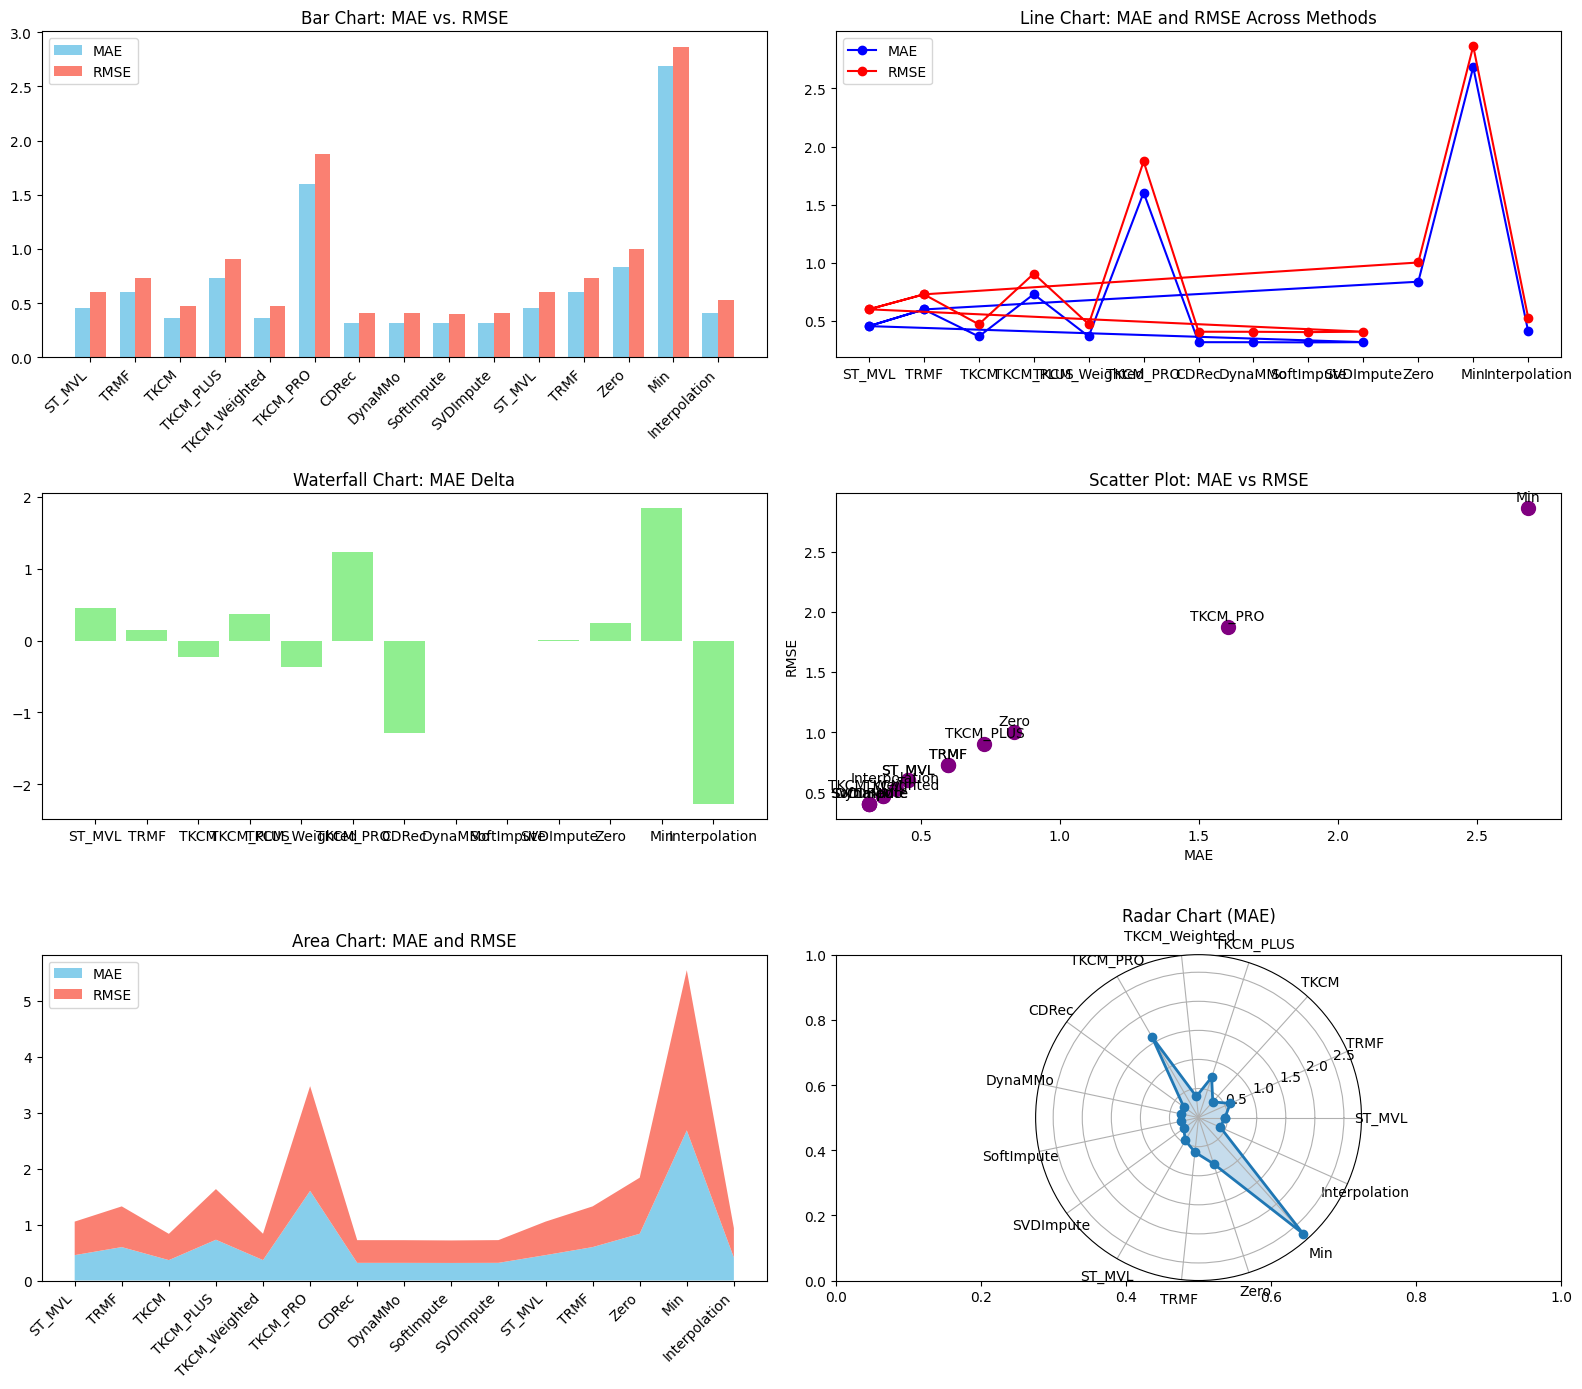

In [57]:
# -----------------------------------------------
# 🔹 STEP 23 (UPDATED): Comparison Chart — MAE vs. RMSE + Extras
# -----------------------------------------------

# Clean and extract
plot_df = results_df.copy()
methods = plot_df["Method"]
mae_scores = plot_df["MAE"]
rmse_scores = plot_df["RMSE"]

x = np.arange(len(methods))  # X-axis positions
width = 0.35

fig, axs = plt.subplots(3, 2, figsize=(16, 14))
axs = axs.flatten()

# --- Bar Chart ---
axs[0].bar(x - width/2, mae_scores, width, label="MAE", color="skyblue")
axs[0].bar(x + width/2, rmse_scores, width, label="RMSE", color="salmon")
axs[0].set_title("Bar Chart: MAE vs. RMSE")
axs[0].set_xticks(x)
axs[0].set_xticklabels(methods, rotation=45, ha="right")
axs[0].legend()

# --- Line Chart ---
axs[1].plot(methods, mae_scores, marker='o', label="MAE", color="blue")
axs[1].plot(methods, rmse_scores, marker='o', label="RMSE", color="red")
axs[1].set_title("Line Chart: MAE and RMSE Across Methods")
axs[1].legend()

# --- Waterfall Chart ---
waterfall_vals = [mae_scores[0]] + [mae_scores[i] - mae_scores[i - 1] for i in range(1, len(mae_scores))]
axs[2].bar(methods, waterfall_vals, color="lightgreen")
axs[2].set_title("Waterfall Chart: MAE Delta")

# --- Scatter Plot ---
axs[3].scatter(mae_scores, rmse_scores, c='purple', s=100)
for i, method in enumerate(methods):
    axs[3].annotate(method, (mae_scores[i], rmse_scores[i]), textcoords="offset points", xytext=(0,5), ha='center')
axs[3].set_xlabel("MAE")
axs[3].set_ylabel("RMSE")
axs[3].set_title("Scatter Plot: MAE vs RMSE")

# --- Area Chart ---
axs[4].stackplot(x, mae_scores, rmse_scores, labels=["MAE", "RMSE"], colors=["skyblue", "salmon"])
axs[4].set_xticks(x)
axs[4].set_xticklabels(methods, rotation=45, ha="right")
axs[4].legend()
axs[4].set_title("Area Chart: MAE and RMSE")

# --- Radar Chart (simulated using polar plot) ---
angles = np.linspace(0, 2 * np.pi, len(methods), endpoint=False).tolist()
scores = mae_scores.tolist()
scores += scores[:1]  # loop
angles += angles[:1]

axs[5] = plt.subplot(3, 2, 6, polar=True)
axs[5].plot(angles, scores, 'o-', linewidth=2)
axs[5].fill(angles, scores, alpha=0.25)
axs[5].set_title("Radar Chart (MAE)")
axs[5].set_xticks(angles[:-1])
axs[5].set_xticklabels(methods)

plt.tight_layout()
plt.show()

